In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("raw_data.csv")
df.head()

,CustomerID,Name,Age,City,Salary,PurchaseAmount
0,101.0,Alice,25.0,Hyderabad,50000.0,200.0
1,102.0,BOB,30.0,Bangalore,60000.0,450.0
2,103.0,charlie,NaN,chennai,55000.0,300.0
3,104.0,David,22.0,Mumbai,NaN,150.0
4,105.0,Eve,28.0,Delhi,70000.0,NaN


In [5]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   CustomerID      9 non-null      float64
 1   Name            9 non-null      object 
 2   Age             8 non-null      float64
 3   City            9 non-null      object 
 4   Salary          9 non-null      float64
 5   PurchaseAmount  9 non-null      float64
dtypes: float64(4), object(2)
memory usage: 612.0+ bytes


,0
CustomerID,1
Name,1
Age,2
City,1
Salary,1
PurchaseAmount,1


In [6]:
df.columns = df.columns.str.strip()

In [7]:
df["Name"] = df["Name"].astype(str).str.strip().str.lower()

In [8]:
df["City"] = df["City"].astype(str).str.strip().str.lower()

In [9]:
# numeric columns → fill mean
for col in df.select_dtypes(include=np.number).columns:
    df[col].fillna(df[col].mean(), inplace=True)

# text columns → fill mode
for col in df.select_dtypes(include='object').columns:
    df[col].fillna(df[col].mode()[0], inplace=True)

/tmp/ipykernel_5648/2973690299.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mean(), inplace=True)
/tmp/ipykernel_5648/2973690299.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try usin

In [10]:
df.drop_duplicates(inplace=True)

In [11]:
df.head(10)

,CustomerID,Name,Age,City,Salary,PurchaseAmount
0,101.000000,alice,25.00,hyderabad,50000.000000,200.0
1,102.000000,bob,30.00,bangalore,60000.000000,450.0
2,103.000000,charlie,29.25,chennai,55000.000000,300.0
3,104.000000,david,22.00,mumbai,65777.777778,150.0
4,105.000000,eve,28.00,delhi,70000.000000,350.0
6,106.000000,frank,35.00,nan,80000.000000,500.0
7,107.000000,george,40.00,pune,90000.000000,600.0
8,104.222222,hannah,29.25,mumbai,65000.000000,350.0
9,109.000000,nan,29.00,delhi,72000.000000,400.0


In [12]:
df.to_csv("cleaned_data.csv", index=False)

In [13]:
report = open("report.txt", "w")

report.write("DATA CLEANING REPORT\n")
report.write("====================\n\n")

report.write(f"Total Rows: {df.shape[0]}\n")
report.write(f"Total Columns: {df.shape[1]}\n\n")

report.write("Missing Values After Cleaning:\n")
report.write(str(df.isnull().sum()))

report.close()

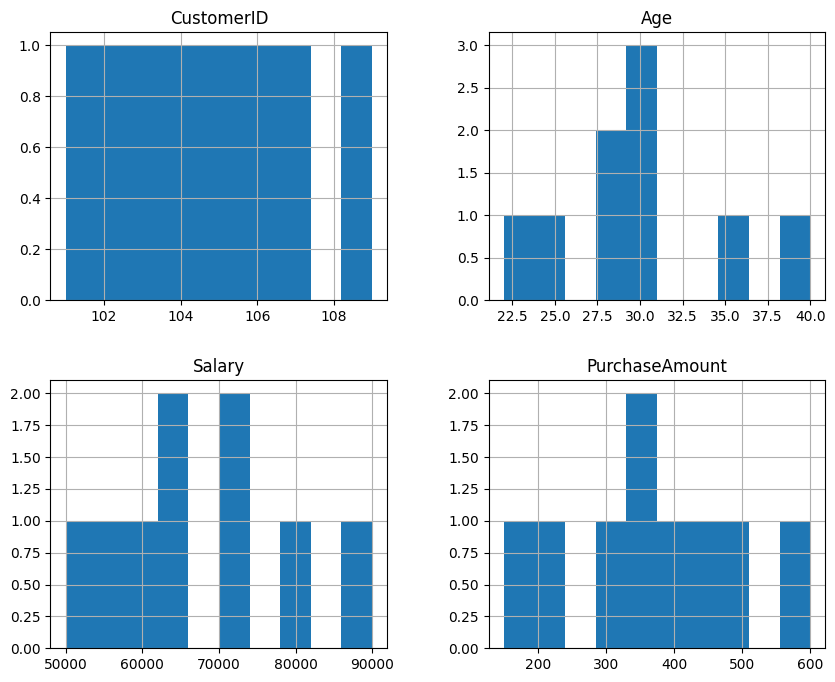

In [14]:
import matplotlib.pyplot as plt

df.hist(figsize=(10,8))
plt.show()